# Course assessment: project part "stock data" (M. Garcin)

- Romain ETIENNE
- Anirudh SUDHIR

## Numerical processing of financial data

#### Objective
The goal of this project is to assess the risk and the performance of a simple portfolio.

- Please write commented code. You can also use text cells for your comments and explanations.
- The code must follow the good coding principles (it must be clean, readable, etc.).
- Graphs must have a title, a legend and their axes must be labeled.
- At the end, submit your notebooks __and a pdf file of 5 to 8 pages__ into the Moodle Assignment you will find in the section "Assessment: projects".
This separate pdf file is intended to be a (very) short paper : a standalone document that summarizes the work you have carried out in the notebooks and the results you have obtained (being they positive or negative), with figures. It has to be self-contained in the sense that one has to be able to read your report and understand its content without having to look into your notebooks, which will be checked afterwards.


In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys
import time

In [2]:
from rich.progress import Progress
import seaborn as sns

In [3]:
# --- Figure saving setup ---
# Figures are exported to report/figures/ in both PDF (LaTeX) and PNG (preview).
# Run this cell before all others to ensure the directory exists.

FIGURES_DIR = os.path.join("report", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)


def save_fig(fig, name: str, dpi: int = 150) -> None:
    """Save a matplotlib figure as PDF (vector, for LaTeX) and PNG (raster, for preview)."""
    fig.savefig(os.path.join(FIGURES_DIR, f"{name}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(FIGURES_DIR, f"{name}.png"), bbox_inches="tight", dpi=dpi)


# Dataset

You will use the dataset (Excel files) of one-minute observations (OHLC prices) provided in Moodle for TP1 (Session 1). The dataset consists in the 40 constituents of the French stock index CAC 40 (as of 2022/2023). The biggest capitalizations are: LVMH (MC), L'Oréal (OR), TotalEnergies (TTE), Sanofi (SAN), Hermès (RMS), Airbus (AIR)...

You have first to restrict arbitrarily your investment universe to ten of these stocks and work with this universe for all the project.

The time range is September 2022-March 2023. Pay attention to the fact that some stocks don't have a price every minute (less liquid, like SW): avoid them.



In [4]:
# %pip install openpyxl  # if needed

begin_date = pd.to_datetime("2022-09-01")
end_date = pd.to_datetime("2023-03-01")

folder_path = 'data/'
df = pd.DataFrame()

with Progress() as p:
    t = p.add_task("[red]Processing files...", total=len(os.listdir(folder_path)))

    for i, filename in enumerate(os.listdir(folder_path)):
        if filename.endswith('.xlsx'):
            file_path = os.path.join(folder_path, filename)

            sub_df = pd.read_excel(file_path, engine='openpyxl', header=1)

            # Enforcing convert to datetime
            if pd.api.types.is_numeric_dtype(sub_df['Dates']):
                sub_df['Dates'] = pd.to_datetime(sub_df['Dates'], unit='d', origin='1899-12-30', errors='coerce')  # type: ignore
                
            sub_df = sub_df[(sub_df['Dates'] >= begin_date) & (sub_df['Dates'] <= end_date)]

            sub_df['Ticker'] = filename.split('_')[0]
            df = pd.concat([df, sub_df], ignore_index=True)
            p.update(t, advance=1)

print(df.head())
print(df.tail())

Output()

                    Dates   Open  Close   High    Low Ticker
0 2022-09-19 09:02:00.005  80.70  80.74  80.76  80.52     SW
1 2022-09-19 09:04:00.000  80.60  80.30  80.60  80.30     SW
2 2022-09-19 09:06:00.000  80.36  80.34  80.38  80.32     SW
3 2022-09-19 09:07:00.000  80.30  80.38  80.38  80.30     SW
4 2022-09-19 09:09:00.000  80.40  80.38  80.40  80.38     SW
                      Dates    Open   Close    High     Low Ticker
2256517 2023-02-28 17:27:00  178.70  178.75  178.80  178.70    CAP
2256518 2023-02-28 17:28:00  178.70  178.70  178.70  178.65    CAP
2256519 2023-02-28 17:29:00  178.70  178.75  178.75  178.70    CAP
2256520 2023-02-28 17:35:00  177.85  177.85  177.85  177.85    CAP
2256521 2023-02-28 17:37:00  177.85  177.85  177.85  177.85    CAP


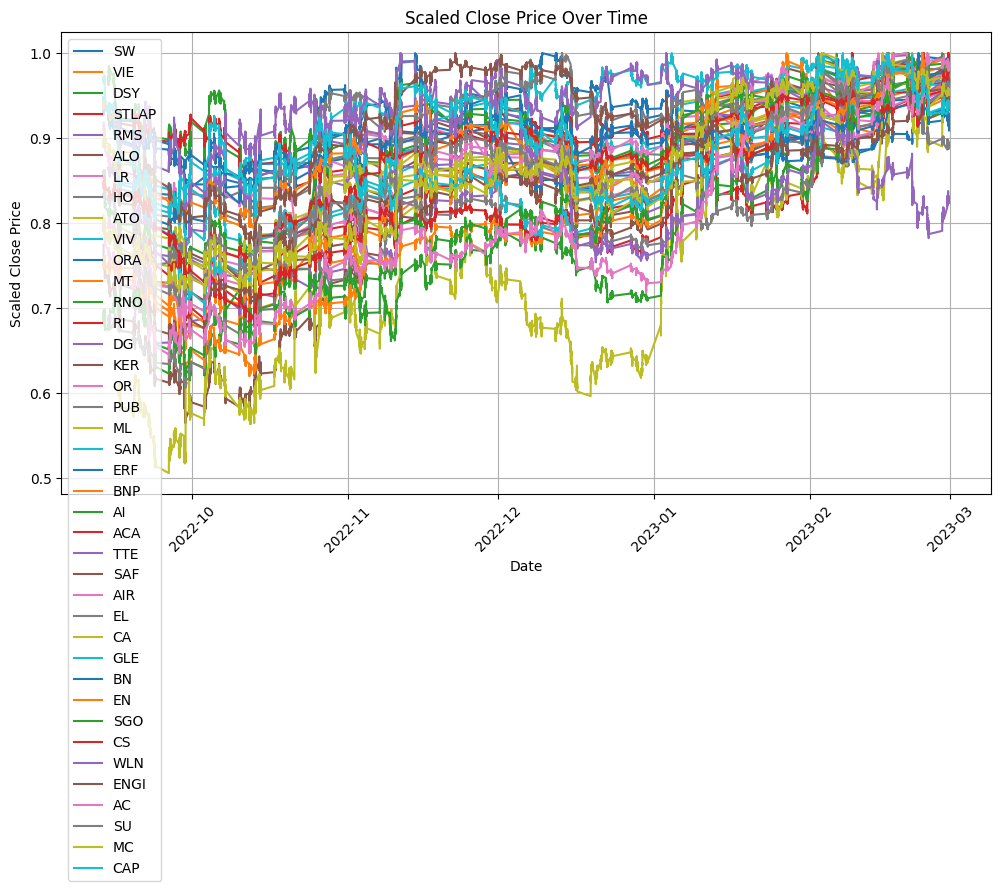

In [5]:
plt.figure(figsize=(12, 6))

for ticker in df["Ticker"].unique():
    grouped = df[df["Ticker"] == ticker]
    plt.plot(grouped["Dates"], grouped["Close"]/grouped["Close"].max(), label=f"{ticker}")

plt.title(f"Scaled Close Price Over Time")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("Scaled Close Price")
plt.legend()
plt.grid()
save_fig(plt.gcf(), "fig_00_scaled_close")
plt.show()


In [6]:
# --- Ticker selection ---
# We restrict to 10 CAC 40 stocks that are:
#   (1) Liquid (all appear in the top half of the dataset by row count)
#   (2) Diversified: one primary sector each, so no single theme dominates
#
# Ticker | Company             | Sector
# -------|---------------------|----------------------------
# MC     | LVMH                | Luxury goods
# TTE    | TotalEnergies       | Energy
# SAN    | Sanofi              | Healthcare / Pharma
# AIR    | Airbus              | Aerospace / Defence
# BNP    | BNP Paribas         | Banking
# CS     | AXA                 | Insurance
# SU     | Schneider Electric  | Industrial / Energy transition
# DSY    | Dassault Systèmes   | Enterprise Software
# MT     | ArcelorMittal       | Materials / Steel
# ORA    | Orange              | Telecom (defensive, dividend)

SELECTED_TICKERS = ["MC", "TTE", "SAN", "AIR", "BNP", "CS", "SU", "DSY", "MT", "ORA"]

df_selected = df[df["Ticker"].isin(SELECTED_TICKERS)].copy()

print(f"Selected tickers : {SELECTED_TICKERS}")
print(f"Date range       : {df_selected['Dates'].min()} → {df_selected['Dates'].max()}")
print("\nRow count per ticker (proxy for liquidity):")
print(df_selected.groupby("Ticker").size().sort_values(ascending=False).to_string())


Selected tickers : ['MC', 'TTE', 'SAN', 'AIR', 'BNP', 'CS', 'SU', 'DSY', 'MT', 'ORA']
Date range       : 2022-09-13 09:00:00 → 2023-02-28 17:38:00

Row count per ticker (proxy for liquidity):
Ticker
MC     61371
BNP    60911
AIR    60769
CS     60150
ORA    59821
TTE    59410
SU     59394
DSY    59276
SAN    58861
MT     58454


# Creating a porfolio (Part 1)

* **1.a/** Split your dataset of prices in separate business days, from day 1 to day $n$. Calculate and put in a dataframe the price returns of the 10 stocks at a daily time scale.



Price days (n)             : 120
Return days (n-1)          : 115

First 3 rows of daily_returns:
Ticker          MC     TTE     SAN     AIR     BNP      CS      SU     DSY  \
Date                                                                         
2022-09-20 -0.0109 -0.0087 -0.0071 -0.0157 -0.0185 -0.0044 -0.0206 -0.0194   
2022-09-21  0.0151  0.0011 -0.0085  0.0152 -0.0098 -0.0006  0.0186  0.0244   
2022-09-22 -0.0291 -0.0002 -0.0030 -0.0110  0.0053 -0.0114 -0.0250 -0.0455   

Ticker          MT     ORA  
Date                        
2022-09-20 -0.0256 -0.0244  
2022-09-21  0.0083 -0.0051  
2022-09-22 -0.0039  0.0094  


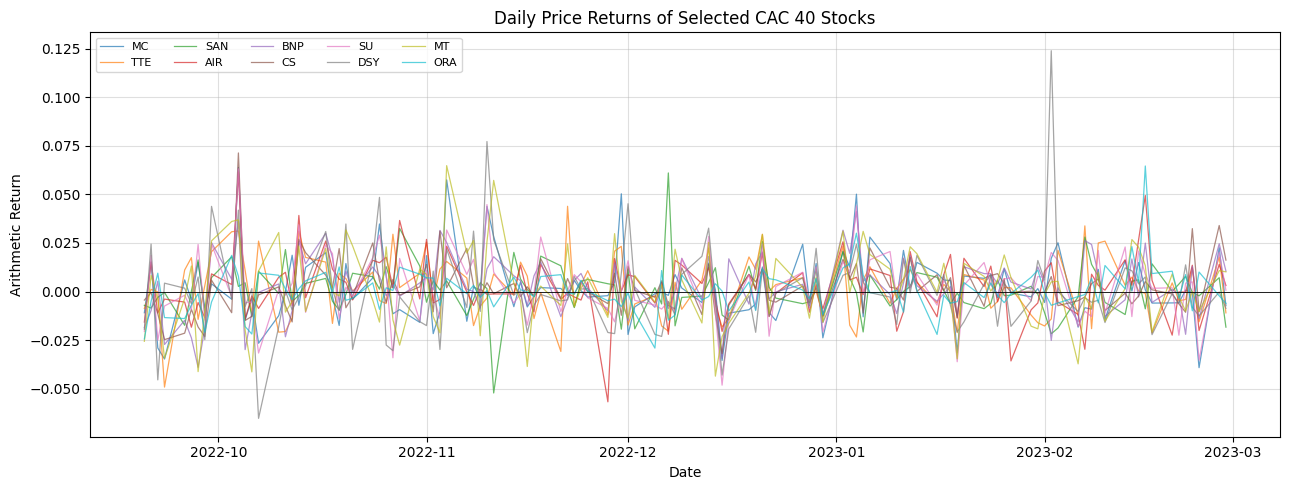

In [7]:
# 1.a — Extract the last Close price of each (day, ticker) pair, then compute
#        arithmetic daily returns: R_{i,j} = (P_{i,j} − P_{i-1,j}) / P_{i-1,j}

daily_close = (
    df_selected.copy()
    .assign(Date=df_selected["Dates"].dt.normalize())   # strip intraday time
    .groupby(["Date", "Ticker"])["Close"]
    .last()                                              # last quote of the day
    .unstack("Ticker")[SELECTED_TICKERS]                 # consistent column order
)

daily_returns = daily_close.pct_change().dropna()
daily_returns.index.name = "Date"

n = len(daily_close)        # number of price days
print(f"Price days (n)             : {n}")
print(f"Return days (n-1)          : {len(daily_returns)}")
print(f"\nFirst 3 rows of daily_returns:")
print(daily_returns.round(4).head(3))

# Visualise
fig, ax = plt.subplots(figsize=(13, 5))
for ticker in daily_returns.columns:
    ax.plot(daily_returns.index, daily_returns[ticker], alpha=0.7, linewidth=0.9, label=ticker)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_title("Daily Price Returns of Selected CAC 40 Stocks")
ax.set_xlabel("Date")
ax.set_ylabel("Arithmetic Return")
ax.legend(ncol=5, fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
save_fig(fig, "fig_01_daily_returns")
plt.show()


* **1.b/** Calculate both the correlation matrix and the covariance matrix $\Sigma$ of the daily price returns of the 10 stocks.

Correlation matrix:
Ticker     MC    TTE    SAN    AIR    BNP     CS     SU    DSY     MT    ORA
Ticker                                                                      
MC      1.000  0.266 -0.054  0.431  0.431  0.379  0.739  0.544  0.462  0.052
TTE     0.266  1.000  0.044  0.263  0.368  0.357  0.167 -0.021  0.448  0.062
SAN    -0.054  0.044  1.000  0.016  0.066  0.104  0.063 -0.082 -0.112  0.181
AIR     0.431  0.263  0.016  1.000  0.461  0.545  0.564  0.337  0.395  0.372
BNP     0.431  0.368  0.066  0.461  1.000  0.636  0.439  0.169  0.543  0.383
CS      0.379  0.357  0.104  0.545  0.636  1.000  0.501  0.214  0.362  0.208
SU      0.739  0.167  0.063  0.564  0.439  0.501  1.000  0.659  0.457  0.165
DSY     0.544 -0.021 -0.082  0.337  0.169  0.214  0.659  1.000  0.269  0.055
MT      0.462  0.448 -0.112  0.395  0.543  0.362  0.457  0.269  1.000  0.244
ORA     0.052  0.062  0.181  0.372  0.383  0.208  0.165  0.055  0.244  1.000

Covariance matrix Σ (daily, ×10⁻⁶):
Ticker      MC     

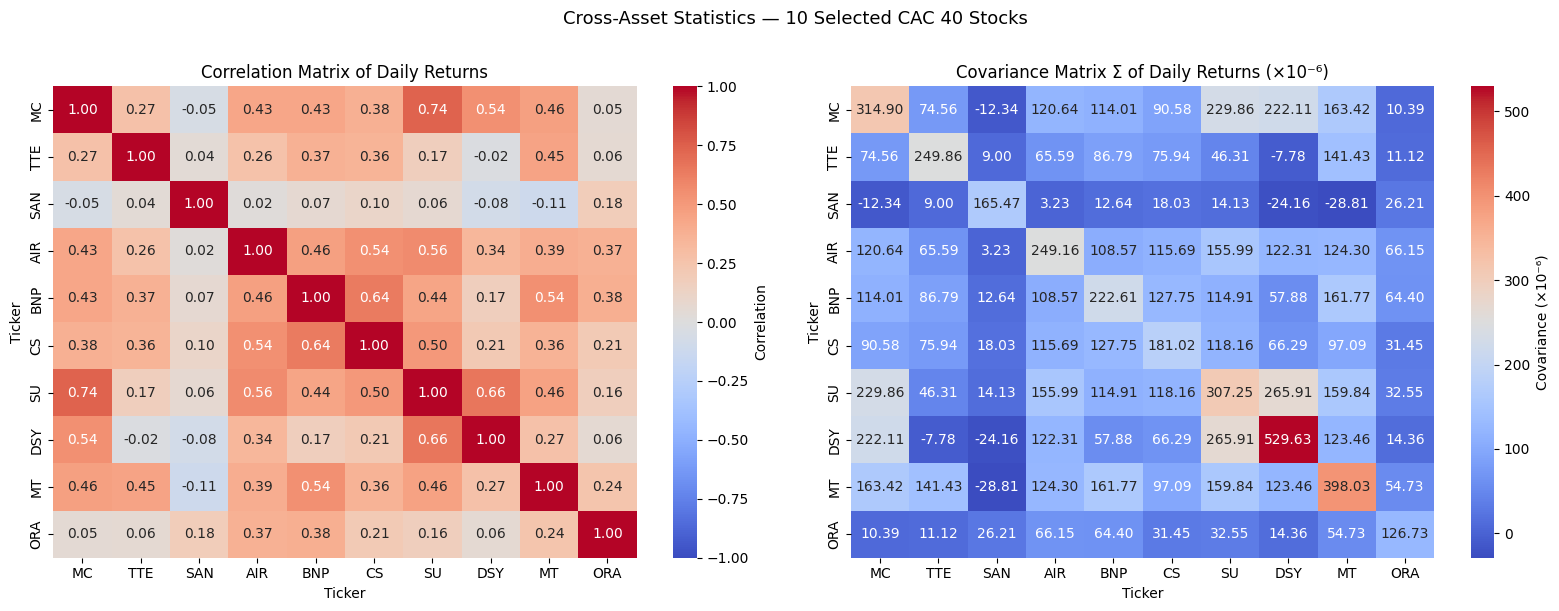

In [8]:
# 1.b — Correlation matrix and covariance matrix Σ of daily price returns.
#        Σ is kept at the daily scale (not annualised) to match the daily
#        return projections used in the Markowitz formula.

corr_matrix = daily_returns.corr()
cov_matrix  = daily_returns.cov()   # Σ (daily)

print("Correlation matrix:")
print(corr_matrix.round(3).to_string())
print("\nCovariance matrix Σ (daily, ×10⁻⁶):")
print((cov_matrix * 1e6).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=axes[0], cbar_kws={"label": "Correlation"})
axes[0].set_title("Correlation Matrix of Daily Returns")

sns.heatmap(cov_matrix * 1e6, annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[1], cbar_kws={"label": "Covariance (×10⁻⁶)"})
axes[1].set_title("Covariance Matrix Σ of Daily Returns (×10⁻⁶)")

plt.suptitle("Cross-Asset Statistics — 10 Selected CAC 40 Stocks", fontsize=13, y=1.01)
plt.tight_layout()
save_fig(fig, "fig_02_corr_cov_matrices")
plt.show()


* **1.c/** For each stock, calculate the autocorrelation of the daily time series of returns, for a lag of one day.

Lag-1 autocorrelation ρ_j per stock:
Ticker
MC    -0.1381
TTE   -0.0671
SAN   -0.1164
AIR   -0.0946
BNP    0.1103
CS    -0.1113
SU    -0.1684
DSY   -0.0244
MT     0.0280
ORA    0.1230


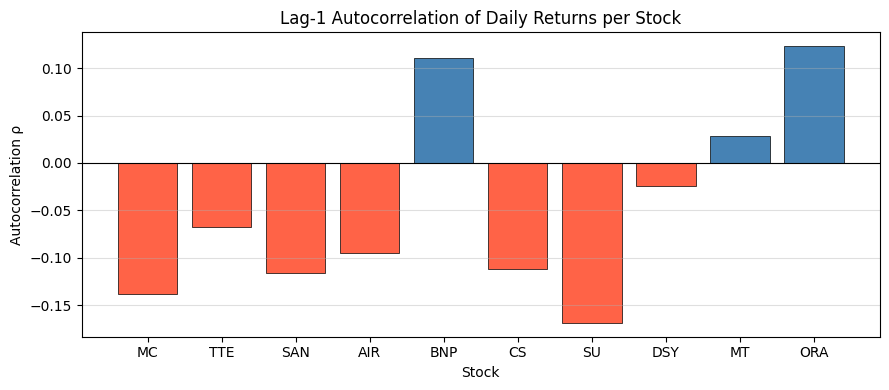

In [9]:
# 1.c — Lag-1 autocorrelation ρ_j of each stock's daily return series.

autocorr = daily_returns.apply(lambda s: s.autocorr(lag=1))

print("Lag-1 autocorrelation ρ_j per stock:")
print(autocorr.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["steelblue" if v >= 0 else "tomato" for v in autocorr.values]
ax.bar(autocorr.index, autocorr.values, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Lag-1 Autocorrelation of Daily Returns per Stock")
ax.set_xlabel("Stock")
ax.set_ylabel("Autocorrelation ρ")
ax.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
save_fig(fig, "fig_03_autocorrelation")
plt.show()


* **1.d/** Using only the autocorrelations calculated above and the observation of the price returns at day $i$ (for $1\leq i\leq n-1$), propose a projection $R_{i+1,j}$ of the future price return at day $i+1$ for each stock $j$ ($1\leq j\leq 10$). Justify briefly the relevance of the method.



Projected returns (first 3 rows):
                 MC      TTE      SAN      AIR      BNP       CS       SU  \
Date                                                                        
2022-09-21  0.00151  0.00059  0.00083  0.00149 -0.00205  0.00049  0.00347   
2022-09-22 -0.00209 -0.00008  0.00099 -0.00144 -0.00108  0.00007 -0.00313   
2022-09-23  0.00401  0.00001  0.00035  0.00104  0.00059  0.00127  0.00422   

                DSY       MT      ORA  
Date                                   
2022-09-21  0.00047 -0.00072 -0.00300  
2022-09-22 -0.00060  0.00023 -0.00063  
2022-09-23  0.00111 -0.00011  0.00116  


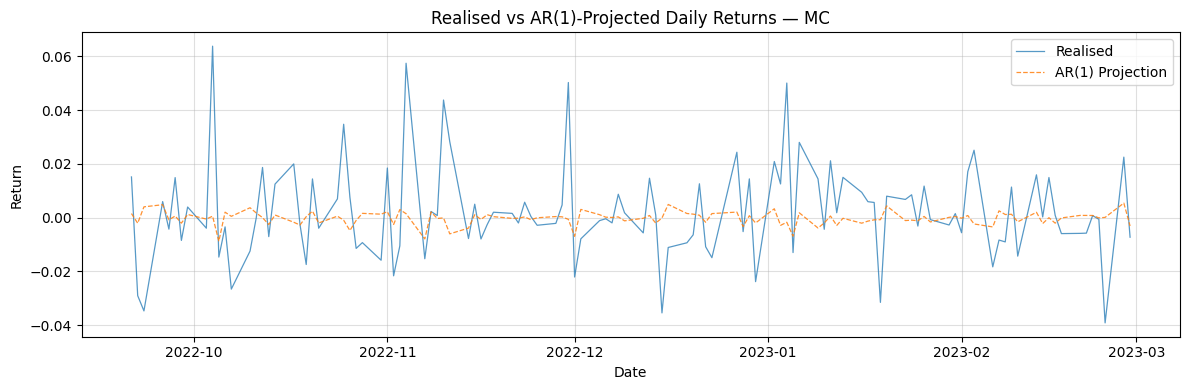

In [10]:
# 1.d — AR(1) projection: R̂_{i+1, j} = ρ_j · R_{i, j}
#
# Justification: under a zero-mean AR(1) model,  R_{i+1} = ρ · R_i + ε_{i+1},
# the best linear one-step-ahead forecast given R_i is  E[R_{i+1} | R_i] = ρ · R_i.
# The autocorrelation ρ_j is the only linear link between consecutive returns,
# so even though it may be small, it represents the maximum extractable
# linear signal from a single lag.

rho = autocorr.values   # shape (10,)

# For day index k in daily_returns (0-based):
#   observed_returns.iloc[k] corresponds to day k
#   the projection targets day k+1 (i.e. daily_returns.index[k+1])
observed_returns  = daily_returns.iloc[:-1]             # days 0 … n-3
projected_values  = observed_returns.values * rho       # broadcast ρ along columns

projected_returns_df = pd.DataFrame(
    projected_values,
    index=daily_returns.index[1:],   # prediction target dates: day 1 … day n-2
    columns=SELECTED_TICKERS,
)

print("Projected returns (first 3 rows):")
print(projected_returns_df.round(5).head(3))

# Visual check: realised vs AR(1) projection for one example stock
ticker_example = "MC"
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_returns.index[1:], daily_returns.loc[daily_returns.index[1:], ticker_example],
        label="Realised", alpha=0.75, linewidth=0.9)
ax.plot(projected_returns_df.index, projected_returns_df[ticker_example],
        label="AR(1) Projection", alpha=0.85, linewidth=0.9, linestyle="--")
ax.set_title(f"Realised vs AR(1)-Projected Daily Returns — {ticker_example}")
ax.set_xlabel("Date")
ax.set_ylabel("Return")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
save_fig(fig, "fig_04_ar1_projection")
plt.show()


* **1.e/** Using the above projection as a proxy for the expected return, calculate the Markowitz portfolio such that the sum of weights is equal to 1, that is the optimal vector of weights for day $i+1$ is
$$\Omega_{i+1}=\frac{1}{\mathbf{1}'_{10}\Sigma^{-1}R_{i+1}}\Sigma^{-1}R_{i+1},$$
where $R_{i+1}=(R_{i+1,1},...,R_{i+1,10})'$ and $\mathbf{1}_{10}$ is a vector of ones of size 10.



Weight-sum check passed (all rows sum to 1.0)

Dynamic weights — first 3 days:
               MC    TTE    SAN    AIR    BNP     CS     SU    DSY     MT  \
Date                                                                        
2022-09-21  0.408 -0.237 -0.426 -0.765  1.090  0.118 -2.035  0.727  0.098   
2022-09-22  0.204 -0.865  3.143 -0.359 -2.256  4.333 -7.155  2.476  2.885   
2022-09-23  0.899  0.007 -0.269 -0.602 -0.635  0.270  1.519 -0.734 -0.564   

              ORA  
Date               
2022-09-21  2.021  
2022-09-22 -1.406  
2022-09-23  1.108  


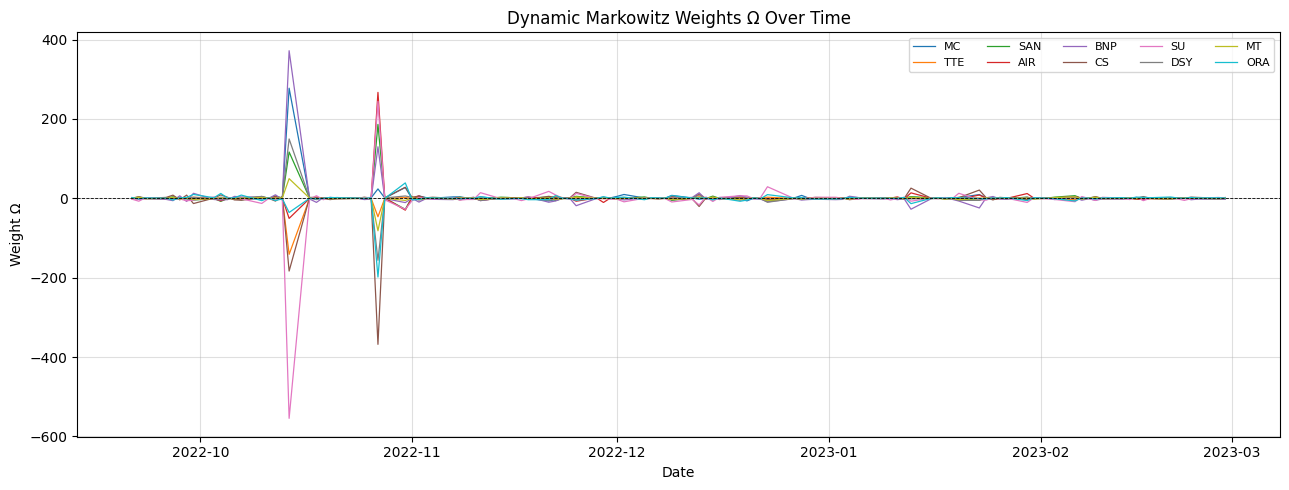

In [11]:
# 1.e — Dynamic Markowitz weights (sum-to-one constraint)
#
# For each day d in projected_returns_df.index:
#   Ω(d) = Σ⁻¹ R̂(d) / (1' Σ⁻¹ R̂(d))
#
# Σ is estimated once on the full sample (see 1.g for the implied bias).

Sigma     = cov_matrix.values        # (10×10), daily covariance
Sigma_inv = np.linalg.inv(Sigma)     # (10×10)


def markowitz_weights(R_proj: np.ndarray, Sigma_inv: np.ndarray) -> np.ndarray:
    """Compute sum-to-1 Markowitz weights given projected returns and Σ⁻¹."""
    raw   = Sigma_inv @ R_proj
    denom = raw.sum()
    if np.abs(denom) < 1e-12:
        # Degenerate case: projected returns are near-zero → equal weights fallback
        return np.full(len(R_proj), 1.0 / len(R_proj))
    return raw / denom


dynamic_weights = np.array([
    markowitz_weights(projected_returns_df.iloc[i].values, Sigma_inv)  # type: ignore
    for i in range(len(projected_returns_df))
])

dynamic_weights_df = pd.DataFrame(
    dynamic_weights,
    index=projected_returns_df.index,
    columns=SELECTED_TICKERS,
)

# Sanity check: all rows must sum to 1
assert np.allclose(dynamic_weights_df.sum(axis=1), 1.0), "Weight sums deviate from 1!"
print("Weight-sum check passed (all rows sum to 1.0)")
print("\nDynamic weights — first 3 days:")
print(dynamic_weights_df.round(3).head(3))

# Time series of Markowitz weights
fig, ax = plt.subplots(figsize=(13, 5))
for ticker in dynamic_weights_df.columns:
    ax.plot(dynamic_weights_df.index, dynamic_weights_df[ticker],
            linewidth=0.9, label=ticker)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("Dynamic Markowitz Weights Ω Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Weight Ω")
ax.legend(ncol=5, fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
save_fig(fig, "fig_05_dynamic_weights")
plt.show()


* **1.f/** Add in your dataframe the time series of realized price returns for your portfolio, between day 2 and day $n$, using the dynamic weights calculated above.



Portfolio return summary:
count    114.00000
mean       0.02690
std        0.97169
min       -5.07370
25%       -0.03590
50%       -0.00376
75%        0.02462
max        8.96755
Name: Portfolio, dtype: float64


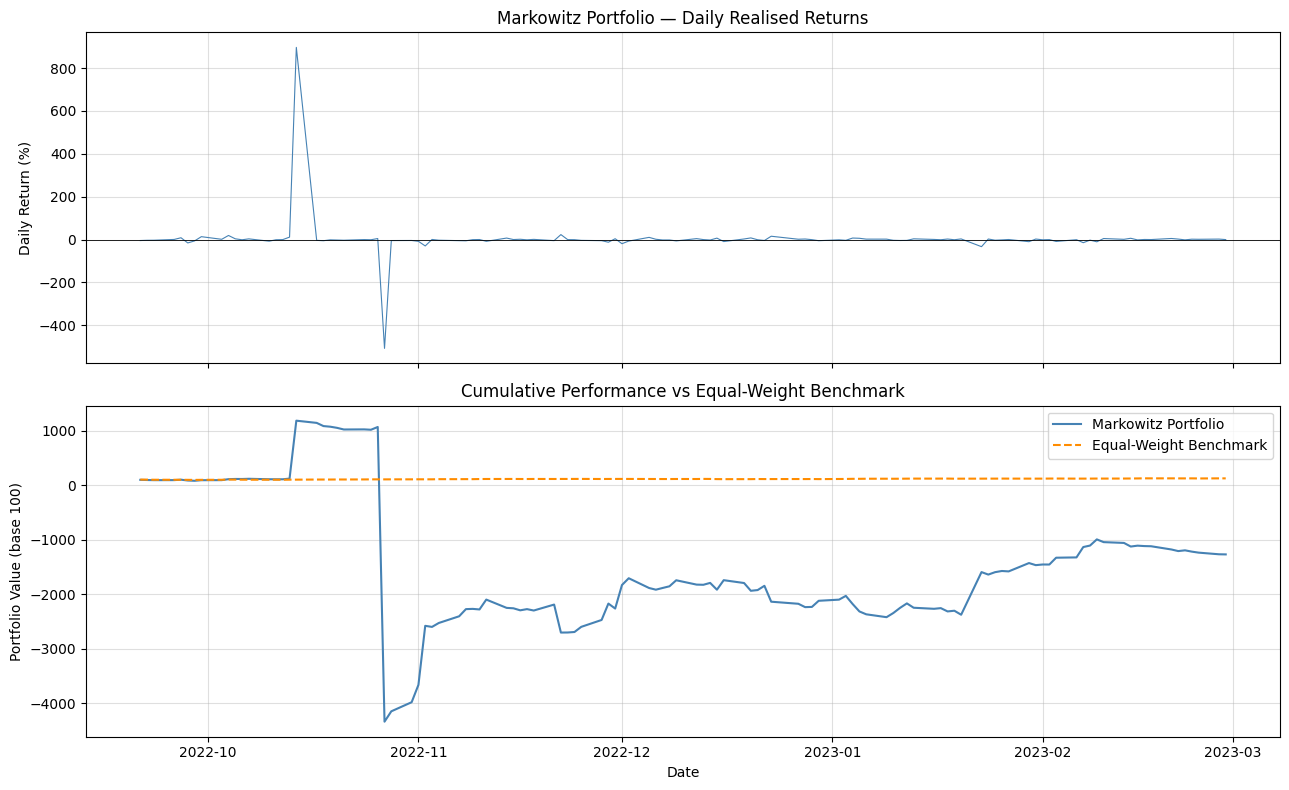

In [12]:
# 1.f — Realised portfolio return on each day d:
#   r_ptf(d) = Ω(d)' · R_realised(d)
# where R_realised(d) are the actual observed returns on day d.

realised_aligned = daily_returns.loc[dynamic_weights_df.index]   # align index

portfolio_returns = pd.Series(
    (dynamic_weights_df.values * realised_aligned.values).sum(axis=1),
    index=dynamic_weights_df.index,
    name="Portfolio",
)

# Append the portfolio column to daily_returns for later use
daily_returns["Portfolio"] = portfolio_returns

print("Portfolio return summary:")
print(portfolio_returns.describe().round(5))

# --- Cumulative performance plot ---
initial_value = 100
ptf_value = initial_value * (1 + portfolio_returns).cumprod()

# Equal-weight index as benchmark
ew_returns = realised_aligned.mean(axis=1)
ew_value   = initial_value * (1 + ew_returns).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(portfolio_returns.index, portfolio_returns * 100,
             linewidth=0.8, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.6)
axes[0].set_ylabel("Daily Return (%)")
axes[0].set_title("Markowitz Portfolio — Daily Realised Returns")
axes[0].grid(True, alpha=0.4)

axes[1].plot(ptf_value.index, ptf_value,
             linewidth=1.5, color="steelblue", label="Markowitz Portfolio")
axes[1].plot(ew_value.index, ew_value,
             linewidth=1.5, color="darkorange", linestyle="--", label="Equal-Weight Benchmark")
axes[1].set_ylabel("Portfolio Value (base 100)")
axes[1].set_xlabel("Date")
axes[1].set_title("Cumulative Performance vs Equal-Weight Benchmark")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
save_fig(fig, "fig_06_portfolio_performance")
plt.show()


* **1.g/** What is the main methodological bias we had in the construction of this portfolio that would affect the quality of a backtest?

**Answer — 1.g**

The main methodological bias is **look-ahead bias** (also called *full-sample bias* or *data snooping*).

The covariance matrix $\Sigma$ is estimated on the **entire** price series from September 2022 to March 2023, including observations that lie strictly in the future relative to any trading day $i$. Because $\Sigma$ implicitly encodes future co-movement structure, the Markowitz weights $\Omega_{i+1}$ are computed with information that would never be available in a real out-of-sample deployment, artificially inflating apparent portfolio quality.

A rigorous backtest would estimate $\Sigma$ from a **rolling or expanding window** of strictly past data (e.g. all days up to and including day $i$), ensuring no future information leaks into the weight computation.


# Risk and performance evaluation (Part 2)

* **2.a/** Determine the ex-ante (that is using $R_{i+1,j}$ as the return) and ex-post (that is the real return observed after each trading day) Sharpe ratio of your portfolio (consider 0 as the risk-free rate).

In [13]:
# 2.a — Sharpe ratio (risk-free rate = 0)
#
# Ex-ante : based on the projected (expected) portfolio return each day,
#            i.e. r̂_ptf(d) = Ω(d)' · R̂(d)
# Ex-post  : based on the realised portfolio return each day,
#            i.e. r_ptf(d) = Ω(d)' · R_realised(d)

# Ex-ante projected portfolio return
ex_ante_ptf_returns = pd.Series(
    (dynamic_weights_df.values * projected_returns_df.values).sum(axis=1),
    index=dynamic_weights_df.index,
    name="Ex-Ante Portfolio Return",
)


def sharpe_ratio(returns: pd.Series, risk_free: float = 0.0, annualise: bool = False) -> float:
    """Sharpe ratio = mean(excess) / std(excess).  Annualise with √252 if requested."""
    excess = returns - risk_free
    sr = excess.mean() / excess.std() if excess.std() > 0 else np.nan
    return sr * np.sqrt(252) if annualise else sr


sr_ante_daily = sharpe_ratio(ex_ante_ptf_returns)
sr_post_daily = sharpe_ratio(portfolio_returns)
sr_ante_ann   = sharpe_ratio(ex_ante_ptf_returns, annualise=True)
sr_post_ann   = sharpe_ratio(portfolio_returns,   annualise=True)

print(f"{'':30s} {'Daily':>10}  {'Annualised':>12}")
print(f"{'Ex-ante Sharpe ratio':30s} {sr_ante_daily:>10.4f}  {sr_ante_ann:>12.4f}")
print(f"{'Ex-post Sharpe ratio':30s} {sr_post_daily:>10.4f}  {sr_post_ann:>12.4f}")


                                    Daily    Annualised
Ex-ante Sharpe ratio               0.0604        0.9595
Ex-post Sharpe ratio               0.0277        0.4394


* **2.b/** Calculate the ex-post upside potential ratio of your portfolio.

In [14]:
# 2.b — Ex-post Upside Potential Ratio (UPR)
#
# UPR = E[max(R, 0)] / sqrt(E[min(R, 0)²])
#     = mean of positive returns / RMS of negative returns
#
# A ratio > 1 means the average gain is larger than the average loss magnitude;
# the higher the ratio, the more asymmetrically favourable the return profile.

r = portfolio_returns.values

positive_returns = r[r > 0]  # type: ignore
negative_returns = r[r < 0]  # type: ignore

upside = positive_returns.mean()  # type: ignore      # mean gain
downside = np.sqrt(
    (negative_returns**2).mean()  # type: ignore
)  # lower partial moment (RMS)

upr = upside / downside

print(f"Mean positive return  (upside)  : {upside:.6f}")
print(f"RMS of negative returns (downside): {downside:.6f}")
print(f"Upside Potential Ratio            : {upr:.4f}")

Mean positive return  (upside)  : 0.211555
RMS of negative returns (downside): 0.654557
Upside Potential Ratio            : 0.3232


* **2.c/** Calculate the maximum drawdown of your portfolio.

Maximum Drawdown : -467.43%
Peak date        : 2022-10-14
Trough date      : 2022-10-27


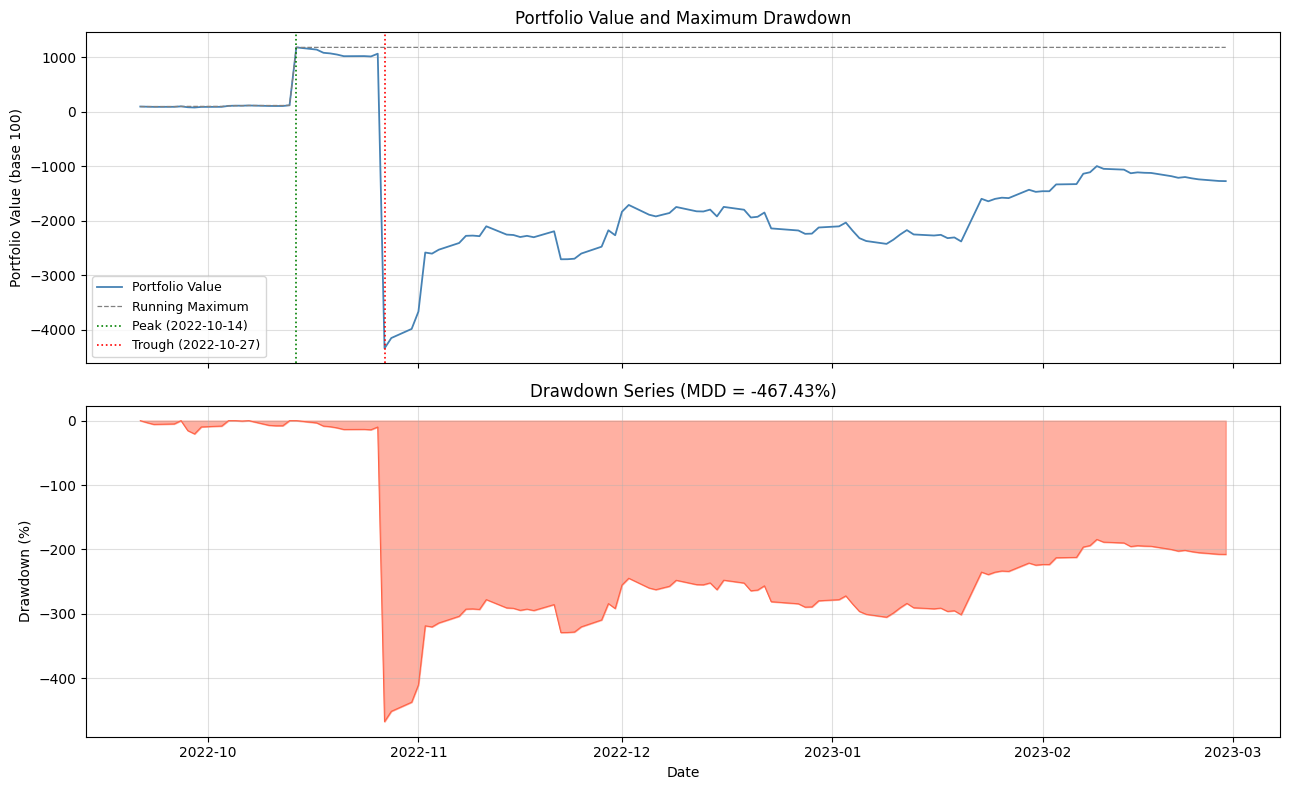

In [15]:
# 2.c — Maximum Drawdown
#
# MDD = max_{t1 < t2}  (V(t1) − V(t2)) / V(t1)
#     = worst peak-to-trough percentage decline of the portfolio value.

def max_drawdown(values: pd.Series):
    """Return (mdd, peak_date, trough_date) for a series of portfolio values."""
    running_max  = values.cummax()
    drawdown     = (values - running_max) / running_max
    trough_date  = drawdown.idxmin()
    peak_date    = running_max.loc[:trough_date].idxmax()
    return drawdown.min(), peak_date, trough_date


mdd, peak_date, trough_date = max_drawdown(ptf_value)

print(f"Maximum Drawdown : {100 * mdd:.2f}%")
print(f"Peak date        : {peak_date.date()}")  # type: ignore
print(f"Trough date      : {trough_date.date()}")  # type: ignore

# Visualise
running_max    = ptf_value.cummax()
drawdown_series = (ptf_value - running_max) / running_max

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(ptf_value.index, ptf_value, color="steelblue", linewidth=1.3, label="Portfolio Value")
axes[0].plot(running_max.index, running_max, color="grey", linewidth=0.9, linestyle="--", label="Running Maximum")
axes[0].axvline(peak_date, color="green", linewidth=1.2, linestyle=":", label=f"Peak ({peak_date.date()})")  # type: ignore
axes[0].axvline(trough_date, color="red", linewidth=1.2, linestyle=":", label=f"Trough ({trough_date.date()})")  # type: ignore
axes[0].set_ylabel("Portfolio Value (base 100)")
axes[0].set_title("Portfolio Value and Maximum Drawdown")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)

axes[1].fill_between(drawdown_series.index, drawdown_series * 100, 0,
                     color="tomato", alpha=0.5)
axes[1].plot(drawdown_series.index, drawdown_series * 100,
             color="tomato", linewidth=0.8)
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Date")
axes[1].set_title(f"Drawdown Series (MDD = {100 * mdd:.2f}%)")
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
save_fig(fig, "fig_07_drawdown")
plt.show()


* **2.d/** Using the formula presented in the course, calculate the additive contribution of each of the 10 stocks to the volatility of the portfolio.

Portfolio daily volatility σ_p  = 0.068574  (annualised: 1.0886)
Cross-check: Σ C_j             = 0.068574  ≈  σ_p

     Mean Weight Ω_j  Marginal contrib (ΣΩ)_j  Additive contrib C_j  Share of σ_p (%)
MC          3.537580                 0.000362              0.018682         27.243361
TTE        -1.338332                -0.000160              0.003131          4.565606
SAN         2.772823                 0.000310              0.012547         18.296723
AIR         1.972992                 0.000063              0.001806          2.633876
BNP         3.054635                 0.000194              0.008623         12.574224
CS         -3.854890                -0.000284              0.015960         23.274311
SU         -3.261198                -0.000149              0.007094         10.345288
DSY        -0.142848                -0.000116              0.000241          0.351312
MT         -0.362463                -0.000085              0.000447          0.651785
ORA        -1.378298    

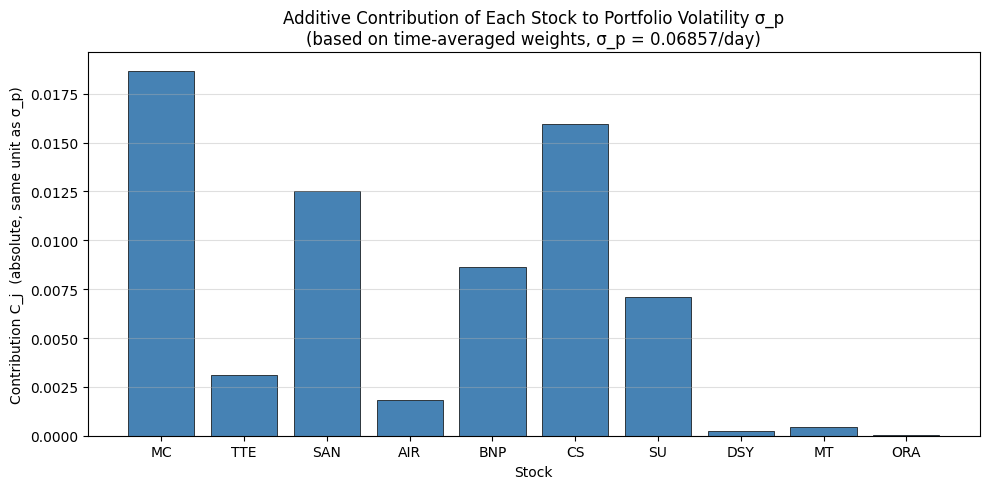

In [16]:
# 2.d — Additive Contribution of Each Stock to Portfolio Volatility
#
# Portfolio variance decomposes exactly as:
#   σ²_p = Ω' Σ Ω = Σ_j  Ω_j · (Σ Ω)_j
#
# Dividing by σ_p gives the additive decomposition of volatility:
#   σ_p = Σ_j  C_j,   with  C_j = Ω_j · (Σ Ω)_j / σ_p
#
# C_j > 0: stock j amplifies portfolio volatility.
# C_j < 0: stock j acts as a hedge (its weight is negative and its contribution reduces σ_p).
# We use the time-averaged weight vector as the representative allocation.

mean_weights = dynamic_weights_df.mean().values        # shape (10,)
sigma_p_sq   = mean_weights @ Sigma @ mean_weights     # portfolio variance
sigma_p      = np.sqrt(sigma_p_sq)                     # portfolio daily volatility

marginal  = Sigma @ mean_weights                       # (Σ Ω), shape (10,)
absolute_contributions = mean_weights * marginal / sigma_p     # C_j
pct_contributions      = 100 * absolute_contributions / sigma_p  # % of σ_p

vol_contrib_df = pd.DataFrame({
    "Mean Weight Ω_j":           mean_weights,
    "Marginal contrib (ΣΩ)_j":   marginal,
    "Additive contrib C_j":      absolute_contributions,
    "Share of σ_p (%)":          pct_contributions,
}, index=SELECTED_TICKERS)

print(f"Portfolio daily volatility σ_p  = {sigma_p:.6f}  "
      f"(annualised: {sigma_p * np.sqrt(252):.4f})")
print(f"Cross-check: Σ C_j             = {absolute_contributions.sum():.6f}  ≈  σ_p")
print()
print(vol_contrib_df.round(6).to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue" if v >= 0 else "tomato" for v in absolute_contributions]
ax.bar(SELECTED_TICKERS, absolute_contributions,
       color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_title("Additive Contribution of Each Stock to Portfolio Volatility σ_p\n"
             f"(based on time-averaged weights, σ_p = {sigma_p:.5f}/day)")
ax.set_xlabel("Stock")
ax.set_ylabel("Contribution C_j  (absolute, same unit as σ_p)")
ax.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
save_fig(fig, "fig_08_vol_contributions")
plt.show()
